In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.interpolate import splrep, splev
from pathlib import Path
from statsmodels.nonparametric.smoothers_lowess import lowess

def interpolate_data(values, num=1000):
    values = np.asarray(values, dtype=float)
    x = np.linspace(0, 1000, len(values))
    spl = splrep(x, values)
    new_x = np.linspace(0, 1000, num)
    new_values = splev(new_x, spl)
    return new_x, new_values


def normalize_data(list):
    list_max = max(list)
    normalized_data_1d = [ (data / list_max)for data in list]
    return normalized_data_1d

import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid

def exp_recovery(x, A, tau, C):
    return C + A * (1 - np.exp(-x / tau))

def fit_one_trace(y):
    y = np.asarray(y, dtype=float)
    x = np.arange(len(y))

    p0 = [
        y[-1] - y[0],   # A
        len(y) / 3,     # tau
        y[0]            # C
    ]

    bounds = (
        [0, 1e-6, -np.inf],      # A >= 0, tau > 0
        [np.inf, np.inf, np.inf]
    )

    popt, _ = curve_fit(
        exp_recovery,
        x,
        y,
        p0=p0,
        bounds=bounds,
        maxfev=10000
    )

    y_fit = exp_recovery(x, *popt)
    return y_fit, popt


def lowess_smooth (data):
    x = np.linspace(0, 1, len(data))
    y = data

    frac = 0.05 # IMPORTANT window length
    lowess_result = lowess(y, x, frac=frac)

    return lowess_result[:,1]



def integral_fraction(y):
    y = np.asarray(y, dtype=float)
    x = np.arange(len(y))
    cum_area = cumulative_trapezoid(y, x, initial=0)

    total_area = cum_area[-1]

    # integral fraction
    frac = cum_area / total_area

    return frac

def integral_fraction_from_baseline(y):
    y = np.asarray(y, dtype=float)

    # baseline = minimum value of this trace
    baseline = np.min(y)

    # shift trace so baseline becomes 0
    y_shifted = y - baseline

    x = np.arange(len(y_shifted))

    cum_area = cumulative_trapezoid(y_shifted, x, initial=0)
    total_area = cum_area[-1]

    frac = cum_area / total_area

    return frac



def calculate_plot_parameter(intensities):
    average = np.mean(intensities, axis=0)
    average = lowess_smooth(average)

    stderr = np.std(intensities, axis=0) / np.sqrt(len(intensities))
    stderr = lowess_smooth(stderr)

    std = np.std(intensities, axis=0)
    std = lowess_smooth(std)

    return average, stderr, std



def plot_blue (intensities, average, stderr, std, time):
    x = np.linspace(0, time, len(average))
    for data in intensities:
        plt.plot(x, data, color='#b6b4b4', alpha=0.65,linewidth=0.5)
        
    plt.plot(x, average, color="#6071f4", linewidth=3, label='Average')
    plt.fill_between(x, average - stderr, average + stderr, color="#8f9cf9", alpha=0.45)
    plt.fill_between(x, average - std, average + std, color='#8f9cf9', alpha=0.15)
    
    plt.xticks(np.arange(0, time, 10))  
    plt.gca().set_xticks(np.arange(0, time, 2), minor=True)  

    plt.xlim(0, time)
    plt.ylim(0.6, 1)

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.xlabel("Time/hour")
    plt.ylabel("Recovered red fraction intensity")

    plt.show()

def plot_red (intensities, average, stderr, std, time):
    x = np.linspace(0, time, len(average))
    for data in intensities:
        plt.plot(x, data, color='#b6b4b4', alpha=0.65,linewidth=0.5)
        
    plt.plot(x, average, color="#DA3839", linewidth=3, label='Average')
    plt.fill_between(x, average - stderr, average + stderr, color="#ED7B7B", alpha=0.45)
    plt.fill_between(x, average - std, average + std, color='#ED7B7B', alpha=0.15)

    plt.xticks(np.arange(0, time, 10)) 
    plt.gca().set_xticks(np.arange(0, time, 2), minor=True) 
    plt.xlim(0, time)

    # plt.ylim(0.6, 1.4)
    plt.ylim(0.6, 1)

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.xlabel("Time/hour")
    plt.ylabel("Recovered red fraction intensity")

    plt.show()


# Figures 6D and 6H

In [30]:
import numpy as np
from scipy.integrate import cumulative_trapezoid



def allinone(input_folder, timestamp_file):

    file_list = sorted(input_folder.glob("*.csv"))

    red_signal_all = []

    blue_signal_all = []

    dye1_signal = []

    dye2_signal = []

    red_fractions = []
    fitted_traces = []
    red_integrals = []

    timestamp_points_location = []

    for i in range(len(file_list)):
        file = file_list[i]
        df = pd.read_csv(file)
        green_data = df["green"] 
        _, green_signal = interpolate_data(green_data, num=1000)

        magenta_data = df["magenta"] 
        _, magenta_signal = interpolate_data(magenta_data, num=1000)

        red_data = df["red"] 
        _, red_signal = interpolate_data(red_data, num=1000)


        blue_data = df["blue"] 
        _, blue_signal = interpolate_data(blue_data, num=1000)


        df_time = pd.read_csv(timestamp_file, header=None)
        row = df_time.iloc[i]  
        timestamp1 = row[0]
        timestamp2 = row[1]

        time1_extend = int(1.1 * timestamp1)
        time2_extend = int(1.1 * timestamp2- 100)

        left_signal = red_signal[:time1_extend]
        right_signal = red_signal[time2_extend:]

        _, interpolate_left = interpolate_data(left_signal, num=1000)
        _, interpolate_right = interpolate_data(right_signal, num=1000)

        relative_left = [(k/np.max(interpolate_left)) for k in interpolate_left]
        relative_right = [(k/np.max(interpolate_right)) for k in interpolate_right]


        interpolate_left_reverse = relative_left[::-1]
        averaged_list_red = [(a + b) / 2 for a, b in zip(interpolate_left_reverse, relative_right)]

        red_signal_all.append(averaged_list_red)

        ## for blue signal
        left_signal = blue_signal[:time1_extend]
        right_signal = blue_signal[time2_extend:]

        _, interpolate_left = interpolate_data(left_signal, num=1000)
        _, interpolate_right = interpolate_data(right_signal, num=1000)

        relative_left = [(k/np.max(interpolate_left)) for k in interpolate_left]
        relative_right = [(k/np.max(interpolate_right)) for k in interpolate_right]

        interpolate_left_reverse = relative_left[::-1]
        averaged_list_blue = [(a + b) / 2 for a, b in zip(interpolate_left_reverse, relative_right)]

        blue_signal_all.append(averaged_list_blue)


        red_fraction = [(a / b) for a, b in zip(averaged_list_red, averaged_list_blue)]
        red_fractions.append(red_fraction[::-1])

        # fit
        y_fit, _ = fit_one_trace(red_fraction[::-1])
        fitted_traces.append(y_fit)

        # area
        new_curve = integral_fraction_from_baseline(red_fraction[::-1])
        red_integrals.append(new_curve)

        # dye1
        dye1_data = normalize_data(green_signal)
        dye1_signal.append(dye1_data)

        # dye2
        dye2_data = normalize_data(magenta_signal)
        dye2_signal.append(dye2_data)

    return dye1_signal, dye2_signal, red_signal_all, blue_signal_all, red_fractions, fitted_traces, red_integrals, timestamp_points_location


def plot_ratio(intensities, average, stderr, std):
    plt.figure(figsize=(4, 3))  
    x = np.linspace(0, 24.2, len(average))  

    for data in intensities:
        plt.plot(x, data, color='#b6b4b4', alpha=0.65, linewidth=0.5)

    plt.plot(x, average, color="#7575EB", linewidth=3, label='Average')

    plt.fill_between(x, average - stderr, average + stderr,
                     color="#9999FF", alpha=0.45)

    plt.fill_between(x, average - std, average + std,
                     color='#9999FF', alpha=0.15) 

    plt.xticks(np.arange(0, 24.2, 10)) 
    plt.gca().set_xticks(np.arange(0, 24.2, 2), minor=True)  

    plt.xlim(0, 24.2)

    plt.ylim(0.6, 1.4)

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.xlabel("Time/hour")
    plt.ylabel("Recovered red fraction intensity")

    plt.show()



def plot_area(intensities, average, stderr, std):
    plt.figure(figsize=(4, 3)) 

    x = np.linspace(0, 24.2, len(average))  

    for data in intensities:
        plt.plot(x, data, color='#b6b4b4', alpha=1, linewidth=0.5)

    plt.plot(x, average, color="#7575EB", linewidth=3, label='Average')

    plt.fill_between(x, average - stderr, average + stderr,
                     color="#9999FF", alpha=0.45)

    plt.fill_between(x, average - std, average + std,
                     color='#9999FF', alpha=0.15) 

    plt.xticks(np.arange(0, 24.2, 10))  
    plt.gca().set_xticks(np.arange(0, 24.2, 2), minor=True) 

    plt.xlim(0, 24.2)

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.xlabel("Time/hour")
    plt.ylabel("red/blue ratio")

    plt.show()


def plot_blue_and_red(average_blue, stderr_blue, std_blue,
                      average_red, stderr_red, std_red,
                      time):

    fig, ax = plt.subplots(figsize=(4, 3))  

    x = np.linspace(0, time, len(average_blue))

    # --- RED ---
    ax.plot(x, average_red, color="#DA3839", linewidth=3)
    ax.fill_between(x, average_red - stderr_red, average_red + stderr_red,
                    color="#ED7B7B", alpha=0.45)
    ax.fill_between(x, average_red - std_red, average_red + std_red,
                    color="#ED7B7B", alpha=0.15)

    # --- BLUE ---
    ax.plot(x, average_blue, color="#57A4FD", linewidth=3)
    ax.fill_between(x, average_blue - stderr_blue, average_blue + stderr_blue,
                    color="#57A4FD", alpha=0.45)
    ax.fill_between(x, average_blue - std_blue, average_blue + std_blue,
                    color="#57A4FD", alpha=0.15)

    # =========================
    # ticks
    # =========================
    ax.set_xlim(0, time)
    ax.set_xticks([0, 10, 20])
    ax.set_xticks(np.arange(0, time + 1, 2), minor=True)


    # =========================
    # style
    # =========================
    ax.set_ylim(0.6, 1)
    ax.set_yticks(np.arange(0.6, 1.01, 0.1))

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.set_xlabel("Time before fixation (h)")
    ax.set_ylabel("Recovered red fraction intensity")

    plt.tight_layout()
    plt.show()



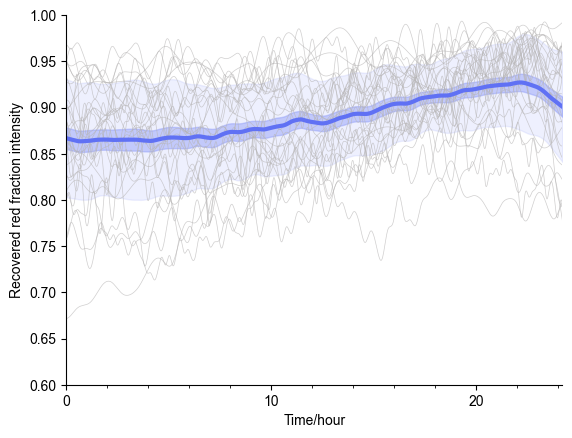

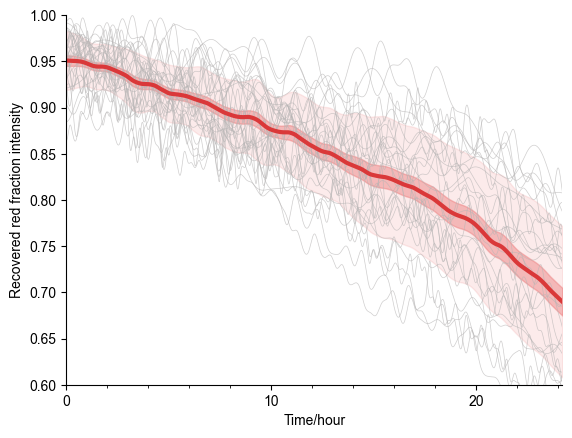

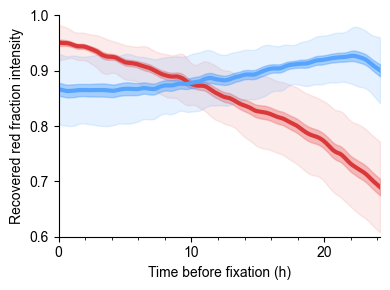

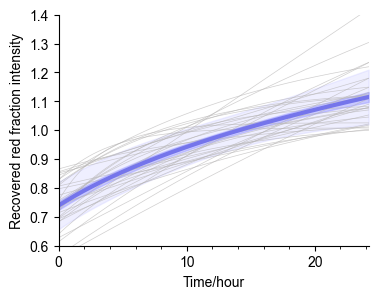

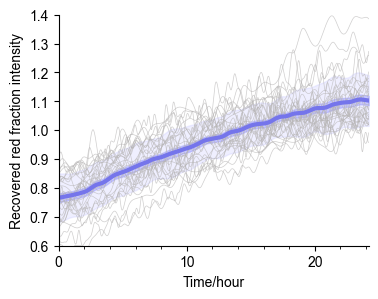

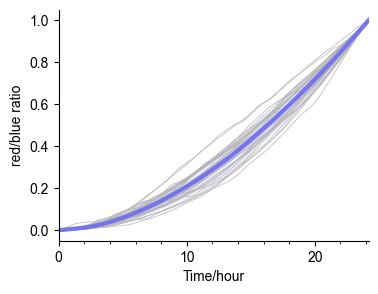

In [ ]:
input_folder = Path(r'Figure 6 46h group\data')
timestamp_file = Path(r'Figure 6 46h group timestamp.csv')

dye1_signal, dye2_signal, red_signal_all, blue_signal_all, red_fractions, fitted_traces_48, red_integrals, timestamp_points_location = allinone(input_folder, timestamp_file)


average_blue_48, stderr_blue, std_blue = calculate_plot_parameter(blue_signal_all)
plot_blue(blue_signal_all, average_blue_48, stderr_blue, std_blue, 24.2)

average_red_48, stderr_red, std_red = calculate_plot_parameter(red_signal_all)
plot_red(red_signal_all, average_red_48, stderr_red, std_red, 24.2)

plot_blue_and_red (average_blue_48, stderr_blue, std_blue,average_red_48, stderr_red, std_red, 24.2)

average_22, stderr_22, std_22 = calculate_plot_parameter(fitted_traces_48)
plot_ratio (fitted_traces_48, average_22, stderr_22, std_22)

average_22, stderr_22, std_22 = calculate_plot_parameter(red_fractions)
plot_ratio (red_fractions, average_22, stderr_22, std_22)

average, stderr, std = calculate_plot_parameter(red_integrals)
plot_area(red_integrals, average, stderr, std)


MAE  = 0.694 hours
RMSE = 0.904 hours


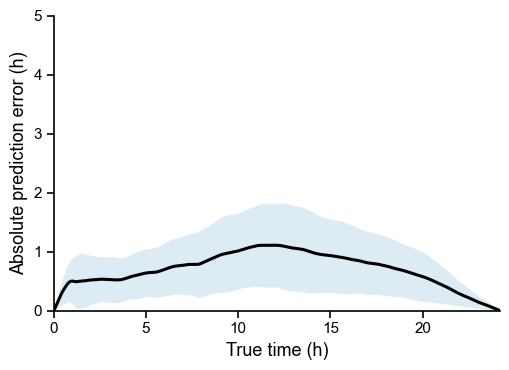

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# =============================
# Input
# =============================
u_calib = np.asarray(average, dtype=float)          
traces = np.asarray(red_integrals, dtype=float)     

t = np.linspace(0, 24.2, 1000)

# =============================
# Step 1: build non-parametric inverse function
# u -> time
# =============================
sort_idx = np.argsort(u_calib)
u_sorted = u_calib[sort_idx]
t_sorted = t[sort_idx]

# remove duplicated u values
u_unique, unique_idx = np.unique(u_sorted, return_index=True)
t_unique = t_sorted[unique_idx]

f_inv = interp1d(
    u_unique,
    t_unique,
    bounds_error=False,
    fill_value="extrapolate"
)

# =============================
# Step 2: calculate signed and absolute error
# =============================
signed_errors = []
abs_errors = []
t_preds = []

for trace in traces:
    u_obs = trace
    t_pred = f_inv(u_obs)

    signed_error = t_pred - t
    abs_error = np.abs(t_pred - t)

    t_preds.append(t_pred)
    signed_errors.append(signed_error)
    abs_errors.append(abs_error)

t_preds = np.array(t_preds)
signed_errors = np.array(signed_errors)
abs_errors = np.array(abs_errors)

# =============================
# Step 3: summary statistics
# =============================
# Signed error = bias
signed_error_mean = np.mean(signed_errors, axis=0)

signed_error_std = np.std(signed_errors, axis=0)
# Absolute error = accuracy
abs_error_mean = np.mean(abs_errors, axis=0)
abs_error_mean_24 = abs_error_mean
abs_error_std = np.std(abs_errors, axis=0)
abs_error_std_24 = abs_error_std

MAE = np.mean(abs_errors)
RMSE = np.sqrt(np.mean(signed_errors**2))

print(f"MAE  = {MAE:.3f} hours")
print(f"RMSE = {RMSE:.3f} hours")

# =============================
# Plot style
# =============================
plt.rcParams["font.family"] = "Arial"
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

# =============================
# Plot 1: Absolute prediction error
# This is your PI's suggested error plot
# =============================
fig, ax = plt.subplots(figsize=(5.2, 3.8))

ax.fill_between(
    t,
    abs_error_mean - abs_error_std,
    abs_error_mean + abs_error_std,
    color="#9EC9E2",
    alpha=0.35,
    linewidth=0,
    label="± SD"
)

ax.plot(
    t,
    abs_error_mean,
    color="black",
    linewidth=2.2,
    label="Mean absolute error"
)

ax.set_xlabel("True time (h)", fontsize=13)
ax.set_ylabel("Absolute prediction error (h)", fontsize=13)

ax.set_xlim(0, 24.2)
ax.set_ylim(0, 5)

ax.tick_params(axis="both", labelsize=11, width=1.2, length=5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

# ax.legend(frameon=False, fontsize=11, loc="upper right")

plt.tight_layout()
plt.show()

# Figure 6C

In [ ]:
import pandas as pd
def normalize_by_max(values):
    values = np.asarray(values, dtype=float)
    vmax = values.max()
    
    if vmax == 0:
        return values
    
    return values / vmax

def plot_together_green_magenta (green_path, magenta_path):
    green_df = pd.read_csv(green_path, skiprows=[1])
    magenta_df = pd.read_csv(magenta_path, skiprows=[1])

    # extract coloumn
    green_df = green_df.iloc[:, 1]
    magenta_df = magenta_df.iloc[:, 1]

    # interpolation
    _, green_trace = interpolate_data(green_df[::-1], num=1000)
    _, magenta_trace = interpolate_data(magenta_df[::-1], num=1000)

    # smooth
    green_trace = lowess_smooth (green_trace)
    magenta_trace = lowess_smooth (magenta_trace)


    green_norm = normalize_by_max(green_trace)
    magenta_norm = normalize_by_max(magenta_trace)

    plt.figure(figsize = (4, 1.5))

    # ===== 1. all =====
    plt.plot(green_norm, color='#8cc63f', linewidth=7, alpha=0.8)
    # axes[0].plot(red_norm, color='#f87977', linewidth=7, alpha=0.8)
    plt.plot(magenta_norm, color='#ff88f4', linewidth=7, alpha=0.8)
    ymin = min(
        green_norm.min()-0.05,
        magenta_norm.min()-0.05
    )
    ymax = max(
        green_norm.max()+0.1,
        magenta_norm.max()+0.1
    )

    plt.ylim(ymin, ymax)
    plt.axis('off')

    plt.show()


def plot_together_blue_red (green_path, magenta_path):
    green_df = pd.read_csv(green_path, skiprows=[1])
    magenta_df = pd.read_csv(magenta_path, skiprows=[1])

    # extract coloumn
    green_df = green_df.iloc[:, 1]
    magenta_df = magenta_df.iloc[:, 1]

    # interpolation
    _, green_trace = interpolate_data(green_df[::-1], num=1000)
    _, magenta_trace = interpolate_data(magenta_df[::-1], num=1000)

    # smooth
    green_trace = lowess_smooth (green_trace)
    magenta_trace = lowess_smooth (magenta_trace)


    green_norm = normalize_by_max(green_trace)
    magenta_norm = normalize_by_max(magenta_trace)

    plt.figure(figsize = (4, 1.5))

    # ===== 1. all =====
    plt.plot(green_norm, color='#57A4FD', linewidth=7, alpha=0.8)
    # axes[0].plot(red_norm, color='#f87977', linewidth=7, alpha=0.8)
    plt.plot(magenta_norm, color='#f87977', linewidth=7, alpha=0.8)
    ymin = min(
        green_norm.min()-0.05,
        magenta_norm.min()-0.05
    )
    ymax = max(
        green_norm.max()+0.1,
        magenta_norm.max()+0.1
    )

    plt.ylim(ymin, ymax)
    plt.axis('off')

    plt.show()


def plot_single_green(path):
    green_df = pd.read_csv(path, skiprows=[1])
    green_df = green_df.iloc[:, 1]
    _, green_trace = interpolate_data(green_df[::-1], num=1000)
    green_trace = lowess_smooth (green_trace)
    plt.figure(figsize = (4, 1.5))
    plt.plot(green_trace, color='#8cc63f', linewidth=7) # magenta: #ff88f4
    plt.axis('off')
    plt.show()

def plot_single_magenta(path):
    green_df = pd.read_csv(path, skiprows=[1])
    green_df = green_df.iloc[:, 1]
    _, green_trace = interpolate_data(green_df[::-1], num=1000)
    green_trace = lowess_smooth (green_trace)
    plt.figure(figsize = (4, 1.5))
    plt.plot(green_trace, color='#ff88f4', linewidth=7) # magenta: #ff88f4
    plt.axis('off')
    plt.show()

def plot_single_red(path):
    green_df = pd.read_csv(path, skiprows=[1])
    green_df = green_df.iloc[:, 1]
    _, green_trace = interpolate_data(green_df[::-1], num=1000)
    green_trace = lowess_smooth (green_trace)
    plt.figure(figsize = (4, 1.5))
    plt.plot(green_trace, color='#f87977', linewidth=7) # magenta: #ff88f4
    plt.axis('off')
    plt.show()


def plot_single_blue(path):
    green_df = pd.read_csv(path, skiprows=[1])
    green_df = green_df.iloc[:, 1]
    _, green_trace = interpolate_data(green_df[::-1], num=1000)
    green_trace = lowess_smooth (green_trace)
    plt.figure(figsize = (4, 1.5))
    plt.plot(green_trace, color="#57A4FD", linewidth=7) # magenta: #ff88f4
    plt.axis('off')
    plt.show()


def lowess_smooth (data):
    x = np.linspace(0, 1, len(data))
    y = data

    frac = 0.05 # IMPORTANT window length
    lowess_result = lowess(y, x, frac=frac)

    return lowess_result[:,1]



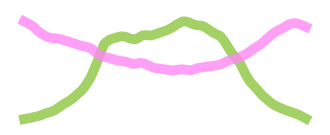

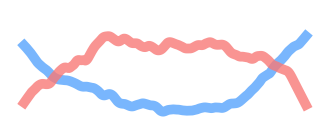

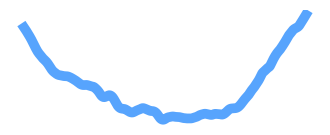

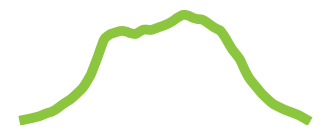

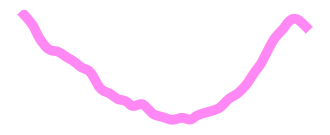

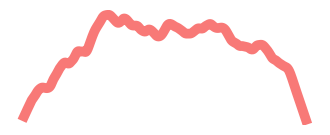

In [ ]:
green_path = r'single traces\example 1 green.csv'
magenta_path = r'single traces\example 1 magenta.csv'
blue_path = r'single traces\example 1 blue.csv'
red_path = r'G:\20260418 fluorescent timer #3\single traces\example 1 red.csv'
plot_together_green_magenta (green_path, magenta_path)
plot_together_blue_red(blue_path, red_path)
plot_single_blue (blue_path)
plot_single_green(green_path)
plot_single_magenta(magenta_path)
plot_single_red(red_path)

# Figure 6E

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. Define each group's raw-data folder and timestamp file
# ============================================================

base_folder = Path(
    r"Figure 6E same cell"
)

group_files = {
    "Cell 1": {
        "input_folder": base_folder / "cell 1" / "data",
        "timestamp_file": base_folder / "cell 1" / "cell 1 timestamp.csv",
    },

    "Cell 2": {
        "input_folder": base_folder / "cell 2" / "data",
        "timestamp_file": base_folder / "cell 2" / "cell 2 timestamp.csv",
    },

    "Cell 3": {
        "input_folder": base_folder / "cell 3" / "data",
        "timestamp_file": base_folder / "cell 3" / "cell 3 timestamp.csv",
    },

    "Cell 4": {
        "input_folder": base_folder / "cell 4" / "data",
        "timestamp_file": base_folder / "cell 4" / "cell 4 timestamp.csv",
    },
    "Others": {
        "input_folder": r'Figure 6E different cell\data',
        "timestamp_file": r'different cell timestamp.csv',
    },
}

In [46]:
from pathlib import Path

group_results = {}
group_traces = {}

for group_name, paths in group_files.items():

    input_folder = Path(paths["input_folder"])
    timestamp_file = Path(paths["timestamp_file"])

    if not input_folder.exists():
        raise FileNotFoundError(
            f"{group_name}: data folder not found:\n{input_folder}"
        )

    if not timestamp_file.exists():
        raise FileNotFoundError(
            f"{group_name}: timestamp file not found:\n{timestamp_file}"
        )

    (
        dye1_signal,
        dye2_signal,
        red_signal_all,
        blue_signal_all,
        red_fractions,
        fitted_traces,
        red_integrals,
        timestamp_points_location,
    ) = allinone(input_folder, timestamp_file)

    group_results[group_name] = {
        "dye1_signal": dye1_signal,
        "dye2_signal": dye2_signal,
        "red_signal_all": red_signal_all,
        "blue_signal_all": blue_signal_all,
        "red_fractions": red_fractions,
        "fitted_traces": fitted_traces,
        "red_integrals": red_integrals,
        "timestamp_points_location": timestamp_points_location,
    }

    group_traces[group_name] = [
        np.asarray(trace, dtype=float)
        for trace in red_fractions
    ]

    print(f"{group_name}: {len(red_fractions)} traces loaded")


Cell 1: 2 traces loaded
Cell 2: 3 traces loaded
Cell 3: 3 traces loaded
Cell 4: 2 traces loaded
Others: 26 traces loaded


In [47]:
# ============================================================
# 3. Pairwise MSE
# ============================================================

def compute_pair_mse(t1, t2):
    """
    Compute MSE between two traces.

    Traces are expected to have the same length.
    """
    t1 = np.asarray(t1, dtype=float)
    t2 = np.asarray(t2, dtype=float)

    if t1.shape != t2.shape:
        raise ValueError(
            f"Trace lengths do not match: "
            f"{t1.shape} versus {t2.shape}"
        )

    return np.nanmean((t1 - t2) ** 2)


def compute_group_mse_matrix_from_traces(group_traces):
    """
    Compute the mean pairwise MSE within and between groups.

    Parameters
    ----------
    group_traces : dict
        Example:
        {
            "Cell 1": [trace1, trace2],
            "Cell 2": [trace1, trace2, trace3],
            ...
        }

    Returns
    -------
    matrix : np.ndarray
        Mean pairwise MSE matrix.

    group_names : list
        Group names in matrix order.
    """

    group_names = list(group_traces.keys())
    n_groups = len(group_names)

    matrix = np.full(
        (n_groups, n_groups),
        np.nan,
        dtype=float,
    )

    for i, group_1 in enumerate(group_names):
        traces_1 = group_traces[group_1]

        for j in range(i, n_groups):
            group_2 = group_names[j]
            traces_2 = group_traces[group_2]

            values = []

            if i == j:
                # Within-group comparisons:
                # compare each pair once and exclude self-comparisons
                for trace_idx_1 in range(len(traces_1)):
                    for trace_idx_2 in range(
                        trace_idx_1 + 1,
                        len(traces_1),
                    ):
                        mse = compute_pair_mse(
                            traces_1[trace_idx_1],
                            traces_1[trace_idx_2],
                        )
                        values.append(mse)

            else:
                # Between-group comparisons:
                # compare every trace in group 1 with every trace in group 2
                for trace_1 in traces_1:
                    for trace_2 in traces_2:
                        mse = compute_pair_mse(
                            trace_1,
                            trace_2,
                        )
                        values.append(mse)

            if len(values) > 0:
                mean_mse = np.nanmean(values)
                matrix[i, j] = mean_mse
                matrix[j, i] = mean_mse

    return matrix, group_names

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from matplotlib.colors import LinearSegmentedColormap, Normalize
import matplotlib.cm as cm

plt.rcParams["font.family"] = "Arial"
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

def rounded_upper_triangle_heatmap(
    matrix,
    labels,
    figsize=(4, 3.5),
    cell_size=0.82,
    rounding=0.18,
    value_fmt=".3f",
    cbar_label="Mean pairwise positional STD"
):
    matrix = np.asarray(matrix)

    cmap_obj = LinearSegmentedColormap.from_list(
        "green_to_pink",
        ["#b7dfd2", "#d47ef1"]
    )

    norm = Normalize(vmin=np.nanmin(matrix), vmax=np.nanmax(matrix))

    n = matrix.shape[0]
    fig, ax = plt.subplots(figsize=figsize)

    for i in range(n):
        for j in range(n):

            # only keep upper triangle, including diagonal
            """ if j > i:
                continue """

            value = matrix[i, j]
            color = cmap_obj(norm(value))

            x = j - cell_size / 2
            y = i - cell_size / 2

            patch = FancyBboxPatch(
                (x, y),
                cell_size,
                cell_size,
                boxstyle=f"round,pad=0.02,rounding_size={rounding}",
                linewidth=0,
                facecolor=color
            )
            ax.add_patch(patch)

            ax.text(
                j, i, format(value, value_fmt),
                ha="center",
                va="center",
                fontsize=10,
                color="black"
            )

    ax.set_xlim(-0.5, n - 0.5)
    ax.set_ylim(n - 0.5, -0.5)

    ax.set_xticks(range(n))
    ax.set_xticklabels(labels, fontsize=11)
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position("top")

    ax.set_yticks(range(n))
    ax.set_yticklabels(labels, fontsize=11)

    ax.tick_params(length=0)

    for spine in ax.spines.values():
        spine.set_visible(False)

    sm = cm.ScalarMappable(norm=norm, cmap=cmap_obj)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.045, pad=0.04)
    cbar.set_label(cbar_label, fontsize=11)
    cbar.outline.set_visible(False)

    plt.tight_layout()
    return fig, ax

Group order: ['Cell 1', 'Cell 2', 'Cell 3', 'Cell 4', 'Others']
RMSE matrix:
[[0.04104607 0.1151593  0.18854174 0.1397589  0.1705694 ]
 [0.1151593  0.04969747 0.09478974 0.09142451 0.10160123]
 [0.18854174 0.09478974 0.07447293 0.12756192 0.10981595]
 [0.1397589  0.09142451 0.12756192 0.04613962 0.10307676]
 [0.1705694  0.10160123 0.10981595 0.10307676 0.11515898]]


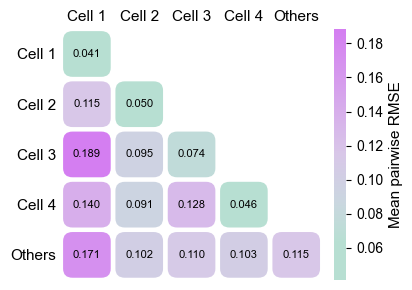

In [48]:
# ============================================================
# 4. Calculate and plot RMSE matrix
# ============================================================

mse_matrix, labels = compute_group_mse_matrix_from_traces(
    group_traces
)

rmse_matrix = np.sqrt(mse_matrix)

print("Group order:", labels)
print("RMSE matrix:")
print(rmse_matrix)

fig, ax = rounded_upper_triangle_heatmap(
    rmse_matrix,
    labels,
    figsize=(4.2, 3),
    cbar_label="Mean pairwise RMSE",
)

plt.show()

Same-cell pairwise comparisons n = 8
Different-cell traces n = 26
Different-cell pairwise comparisons n = 325
Mann–Whitney U = 273.0
p = 1.851019243966072e-05
Same-cell median MSE = 0.0028304028614463527
Different-cell median MSE = 0.010333369807665497


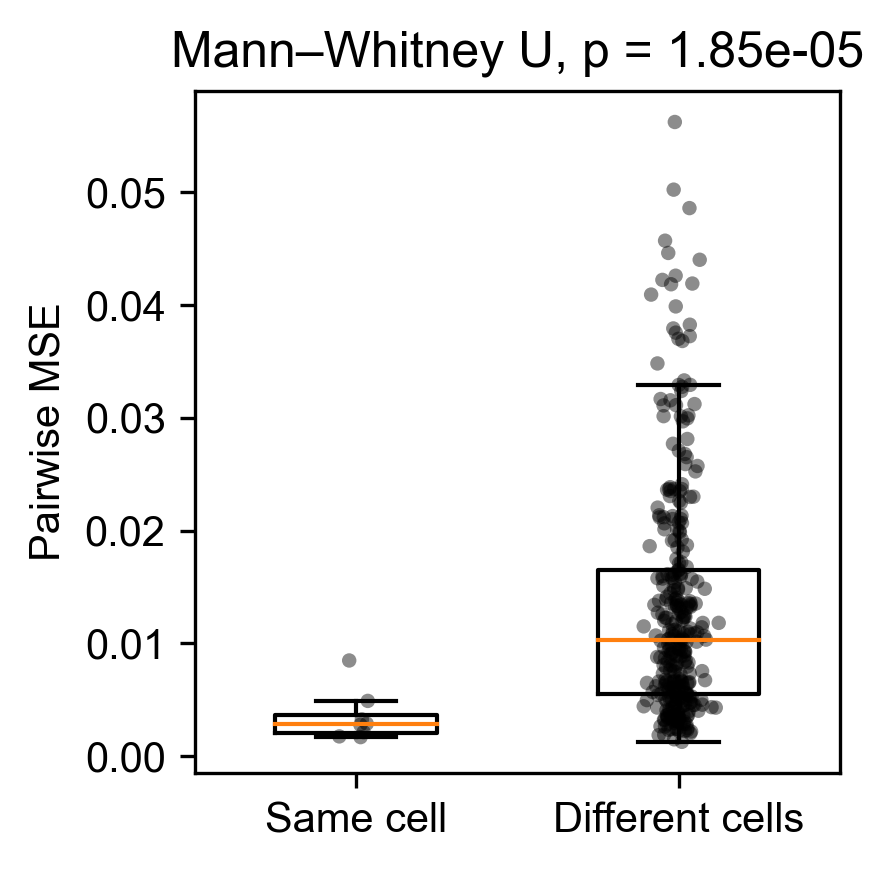

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu


same_cell_group_names = [
    "Cell 1",
    "Cell 2",
    "Cell 3",
    "Cell 4",
]

different_cell_group_name = "Others"

records = []


# ============================================================
# 1. Same-cell pairwise MSE
# Cell 1–4: calculate pairs only within each cell
# ============================================================

for group_name in same_cell_group_names:

    traces = group_traces[group_name]

    for i in range(len(traces)):
        for j in range(i + 1, len(traces)):

            mse = compute_pair_mse(
                traces[i],
                traces[j],
            )

            records.append({
                "comparison": "Same cell",
                "group": group_name,
                "trace_1": i,
                "trace_2": j,
                "mse": mse,
            })


# ============================================================
# 2. Different-cell pairwise MSE
# Use pairwise comparisons within the Others group
# ============================================================

other_traces = group_traces[different_cell_group_name]

for i in range(len(other_traces)):
    for j in range(i + 1, len(other_traces)):

        mse = compute_pair_mse(
            other_traces[i],
            other_traces[j],
        )

        records.append({
            "comparison": "Different cells",
            "group": different_cell_group_name,
            "trace_1": i,
            "trace_2": j,
            "mse": mse,
        })


comparison_df = pd.DataFrame(records)


# ============================================================
# 3. Extract values
# ============================================================

same_cell_mse = comparison_df.loc[
    comparison_df["comparison"] == "Same cell",
    "mse",
].dropna().values

different_cell_mse = comparison_df.loc[
    comparison_df["comparison"] == "Different cells",
    "mse",
].dropna().values


print("Same-cell pairwise comparisons n =", len(same_cell_mse))
print("Different-cell traces n =", len(other_traces))
print("Different-cell pairwise comparisons n =", len(different_cell_mse))


# ============================================================
# 4. Mann–Whitney U test
# ============================================================

stat, p = mannwhitneyu(
    same_cell_mse,
    different_cell_mse,
    alternative="two-sided",
)

print("Mann–Whitney U =", stat)
print("p =", p)

print("Same-cell median MSE =", np.nanmedian(same_cell_mse))
print("Different-cell median MSE =", np.nanmedian(different_cell_mse))


# ============================================================
# 5. Plot
# ============================================================

plt.figure(figsize=(3, 3), dpi=300)

plot_data = [
    same_cell_mse,
    different_cell_mse,
]

plot_labels = [
    "Same cell",
    "Different cells",
]

plt.boxplot(
    plot_data,
    labels=plot_labels,   # older Matplotlib uses labels
    showfliers=False,
    widths=0.5,
)

rng = np.random.default_rng(1)

for x_position, values in enumerate(plot_data, start=1):

    jitter = rng.normal(
        loc=0,
        scale=0.04,
        size=len(values),
    )

    plt.scatter(
        np.full(len(values), x_position) + jitter,
        values,
        s=12,
        alpha=0.45,
        color="black",
        edgecolors="none",
    )

plt.ylabel("Pairwise MSE")
plt.title(f"Mann–Whitney U, p = {p:.2e}")

plt.tight_layout()
plt.show()

# Figure S9

In [ ]:
import numpy as np
from scipy.integrate import cumulative_trapezoid



def allinone(input_folder, timestamp_file):

    file_list = sorted(input_folder.glob("*.csv"))

    red_signal_all = []

    blue_signal_all = []

    dye1_signal = []

    dye2_signal = []

    red_fractions = []
    fitted_traces = []
    red_integrals = []

    timestamp_points_location = []

    for i in range(len(file_list)):
        file = file_list[i]
        df = pd.read_csv(file)
        green_data = df["green"] 
        _, green_signal = interpolate_data(green_data, num=1000)

        magenta_data = df["magenta"] 
        _, magenta_signal = interpolate_data(magenta_data, num=1000)

        red_data = df["red"] 
        _, red_signal = interpolate_data(red_data, num=1000)


        blue_data = df["blue"] 
        _, blue_signal = interpolate_data(blue_data, num=1000)


        df_time = pd.read_csv(timestamp_file, header=None)
        row = df_time.iloc[i]  
        timestamp1 = row[0]
        timestamp2 = row[1]

        time1_extend = int(1 * timestamp1)
        time2_extend = int(1 * timestamp2) # no extension!!!!


        left_signal = red_signal[:time1_extend]
        right_signal = red_signal[time2_extend:]

        _, interpolate_left = interpolate_data(left_signal, num=1000)
        _, interpolate_right = interpolate_data(right_signal, num=1000)

        # baseline = np.max(red_signal)

        relative_left = [(k/np.max(interpolate_left)) for k in interpolate_left]
        relative_right = [(k/np.max(interpolate_right)) for k in interpolate_right]


        interpolate_left_reverse = relative_left[::-1]
        averaged_list_red = [(a + b) / 2 for a, b in zip(interpolate_left_reverse, relative_right)]

        red_signal_all.append(averaged_list_red)


        ## for blue signal
        left_signal = blue_signal[:time1_extend]
        right_signal = blue_signal[time2_extend:]

        _, interpolate_left = interpolate_data(left_signal, num=1000)
        _, interpolate_right = interpolate_data(right_signal, num=1000)

        relative_left = [(k/np.max(interpolate_left)) for k in interpolate_left]
        relative_right = [(k/np.max(interpolate_right)) for k in interpolate_right]

        interpolate_left_reverse = relative_left[::-1]
        averaged_list_blue = [(a + b) / 2 for a, b in zip(interpolate_left_reverse, relative_right)]

        blue_signal_all.append(averaged_list_blue)


        red_fraction = [(a / b) for a, b in zip(averaged_list_red, averaged_list_blue)]
        red_fractions.append(red_fraction[::-1])

        # fit
        y_fit, _ = fit_one_trace(red_fraction[::-1])
        fitted_traces.append(y_fit)

        # area
        new_curve = integral_fraction_from_baseline(red_fraction[::-1])
        red_integrals.append(new_curve)

        # dye1
        dye1_data = normalize_data(red_signal)
        dye1_signal.append(dye1_data)

        # dye2
        dye2_data = normalize_data(blue_signal)
        dye2_signal.append(dye2_data)

    return dye1_signal, dye2_signal, red_signal_all, blue_signal_all, red_fractions, fitted_traces, red_integrals, timestamp_points_location


def plot_ratio(intensities, average, stderr, std):
    plt.figure(figsize=(4, 3))  
    x = np.linspace(0, 18.15, len(average))  

    for data in intensities:
        plt.plot(x, data, color='#b6b4b4', alpha=0.65, linewidth=0.5)

    plt.plot(x, average, color="#7575EB", linewidth=3, label='Average')

    plt.fill_between(x, average - stderr, average + stderr,
                     color="#9999FF", alpha=0.45)

    plt.fill_between(x, average - std, average + std,
                     color='#9999FF', alpha=0.15) 


    plt.xticks(np.arange(0, 18.15, 10))  
    plt.gca().set_xticks(np.arange(0, 18.15, 2), minor=True)  

    plt.xlim(0, 18.15)
    plt.ylim(0.6, 1.4)

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.xlabel("Time/hour")
    plt.ylabel("Recovered red fraction intensity")

    plt.show()



def plot_area(intensities, average, stderr, std):
    plt.figure(figsize=(4, 3)) 

    x = np.linspace(0, 18.15, len(average))  

    for data in intensities:
        plt.plot(x, data, color='#b6b4b4', alpha=1, linewidth=0.5)

    plt.plot(x, average, color="#9999FF", linewidth=3, label='Average')

    plt.fill_between(x, average - stderr, average + stderr,
                     color="#9999FF", alpha=0.65)

    plt.fill_between(x, average - std, average + std,
                     color='#9999FF', alpha=0.45) 

    plt.xticks(np.arange(0, 18.15, 10))  
    plt.gca().set_xticks(np.arange(0, 18.15, 2), minor=True)  

    plt.xlim(0, 18.15)

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.xlabel("Time/hour")
    plt.ylabel("red/blue ratio")

    plt.show()


def plot_blue_and_red(average_blue, stderr_blue, std_blue,
                      average_red, stderr_red, std_red,
                      time):

    fig, ax = plt.subplots(figsize=(4, 3))  

    x = np.linspace(0, time, len(average_blue))

    # --- RED ---
    ax.plot(x, average_red, color="#DA3839", linewidth=3)
    ax.fill_between(x, average_red - stderr_red, average_red + stderr_red,
                    color="#ED7B7B", alpha=0.45)
    ax.fill_between(x, average_red - std_red, average_red + std_red,
                    color="#ED7B7B", alpha=0.15)

    # --- BLUE ---
    ax.plot(x, average_blue, color="#57A4FD", linewidth=3)
    ax.fill_between(x, average_blue - stderr_blue, average_blue + stderr_blue,
                    color="#57A4FD", alpha=0.45)
    ax.fill_between(x, average_blue - std_blue, average_blue + std_blue,
                    color="#57A4FD", alpha=0.15)

    # =========================
    # ticks
    # =========================

    ax.set_xlim(0, time)
    ax.set_xticks([0, 10, 20])
    ax.set_xticks(np.arange(0, time + 1, 2), minor=True)


    # =========================
    # style
    # =========================
    ax.set_ylim(0.6, 1)
    ax.set_yticks(np.arange(0.6, 1.01, 0.1))

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.set_xlabel("Time before fixation (h)")
    ax.set_ylabel("Recovered red fraction intensity")

    plt.tight_layout()
    plt.show()



In [ ]:
timestamp_path = r"Figure 6 46h group\Figure 6 46h FT plateau.csv"
plateau_path = r"Figure 6 46h group\Figure 6 46h FT plateau.csv"

df_timestamp = pd.read_csv(timestamp_path, header=None)
df_plateau = pd.read_csv(plateau_path, header=None)

ratios_ori = []

for i in range(len(df_timestamp)):
    timestamp1 = float(df_timestamp.iloc[i, 0])
    timestamp2 = float(df_timestamp.iloc[i, 1])

    plateau1 = float(df_plateau.iloc[i, 0])
    plateau2 = float(df_plateau.iloc[i, 1])

    r1 = plateau1 / timestamp1
    r2 = (1000 - plateau2) / (1000 - timestamp2)

    # ratios_ori.extend([r1, r2])
    mean = (r1+r2)/2
    if mean<1.1:
        ratios_ori.append(mean)
real_time_22 = [(22*i) for i in ratios_ori]

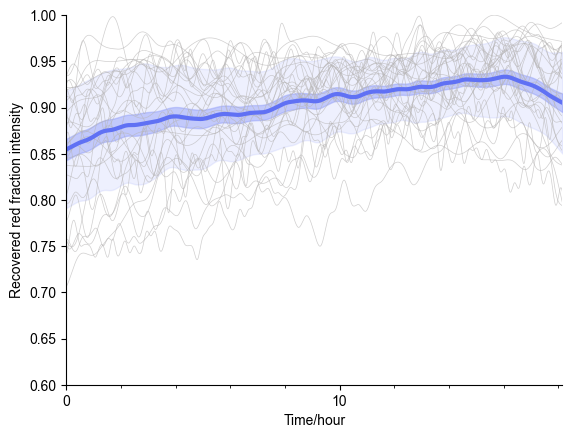

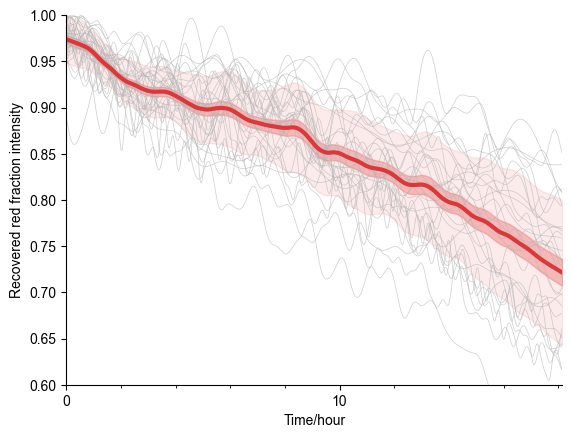

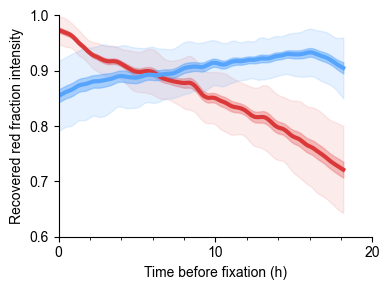

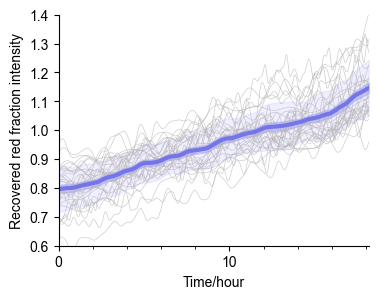

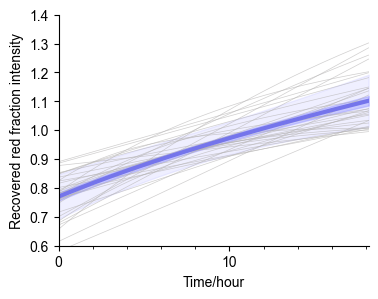

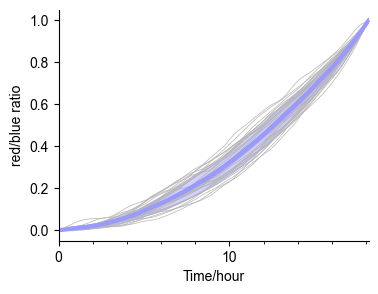

In [ ]:
input_folder = Path(r'Figure 6 46h group\data')
timestamp_file = Path(r"Figure 6 46h FT plateau.csv")

dye1_signal, dye2_signal, red_signal_all, blue_signal_all, red_fractions, fitted_traces_48, red_integrals, timestamp_points_location = allinone(input_folder, timestamp_file)


average_1, stderr_1, std = calculate_plot_parameter(dye1_signal)
average_2, stderr_2, std = calculate_plot_parameter(dye2_signal)


average_blue_48, stderr_blue, std_blue = calculate_plot_parameter(blue_signal_all)
plot_blue(blue_signal_all, average_blue_48, stderr_blue, std_blue, 18.15)

average_red_48, stderr_red, std_red = calculate_plot_parameter(red_signal_all)
plot_red(red_signal_all, average_red_48, stderr_red, std_red, 18.15)

plot_blue_and_red (average_blue_48, stderr_blue, std_blue,average_red_48, stderr_red, std_red, 18.15)

average, stderr, std = calculate_plot_parameter(red_fractions)
plot_ratio (red_fractions, average, stderr, std)

average, stderr, std = calculate_plot_parameter(fitted_traces_48)
plot_ratio(fitted_traces_48, average, stderr, std)

average_22, stderr_22, std_22 = calculate_plot_parameter(red_integrals)
plot_area (red_integrals, average_22, stderr_22, std_22)


# Figure 6M

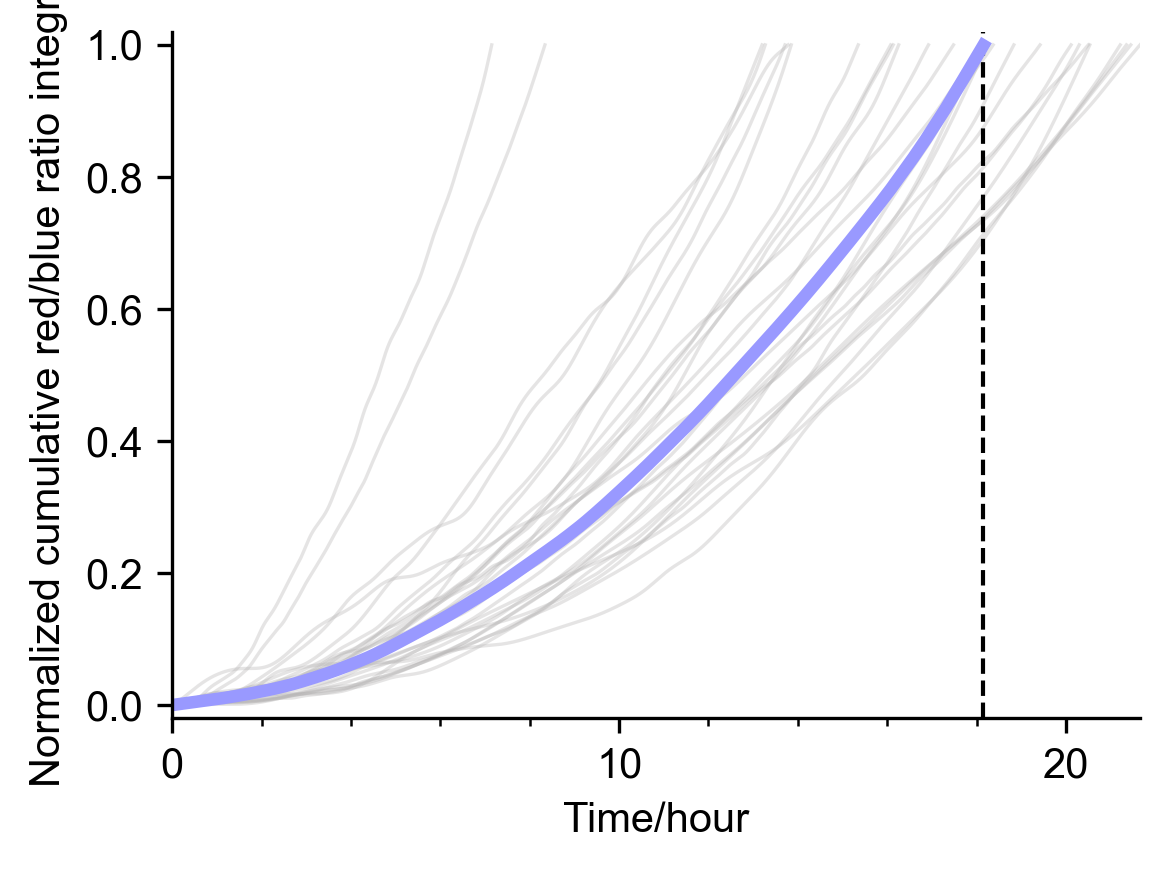

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

estimated_time_max = 18.15

plt.figure(figsize=(4, 3), dpi=300)

for trace, real_time in zip(red_integrals, real_time_22):
    trace = np.asarray(trace, dtype=float)
    x_real = np.linspace(0, real_time, len(trace))

    plt.plot(
        x_real,
        trace,
        color="#b6b4b4",
        alpha=0.35,
        linewidth=0.8
    )

calibration_curve = np.asarray(average_22, dtype=float)
x_calib = np.linspace(0, estimated_time_max, len(calibration_curve))
plt.axvline(x=estimated_time_max, color="black", linestyle="--", linewidth=1)
plt.plot(
    x_calib,
    calibration_curve,
    color="#9999FF",
    linewidth=3,
    label="Calibration curve"
)

x_max = max(max(real_time_22), estimated_time_max)

# ticks use real time values
plt.xticks(np.arange(0, x_max + 0.1, 10))
plt.gca().set_xticks(np.arange(0, x_max + 0.1, 2), minor=True)

plt.xlim(0, x_max)
plt.ylim(-0.02, 1.02)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)


plt.xlabel("Time/hour")
plt.ylabel("Normalized cumulative red/blue ratio integral")

plt.tight_layout()
plt.show()